In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("House price Prediction Project Load Successfully")

House price Prediction Project Load Successfully


In [2]:
df = pd.read_csv("Housing.csv")

print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [3]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(545, 13)


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB
None


In [5]:
print(df.describe())

              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [6]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [7]:
print("Duplicate Rows:")

print(df.duplicated().sum())

Duplicate Rows:
0


In [8]:
df = df.drop_duplicates()

print(df.shape)

(545, 13)


In [9]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [10]:
print(df.nunique())

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64


In [11]:
print(
    df.select_dtypes(
        include='object'
    ).columns
)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


C:\Users\Ganesh\AppData\Local\Temp\ipykernel_1672\3205266899.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(


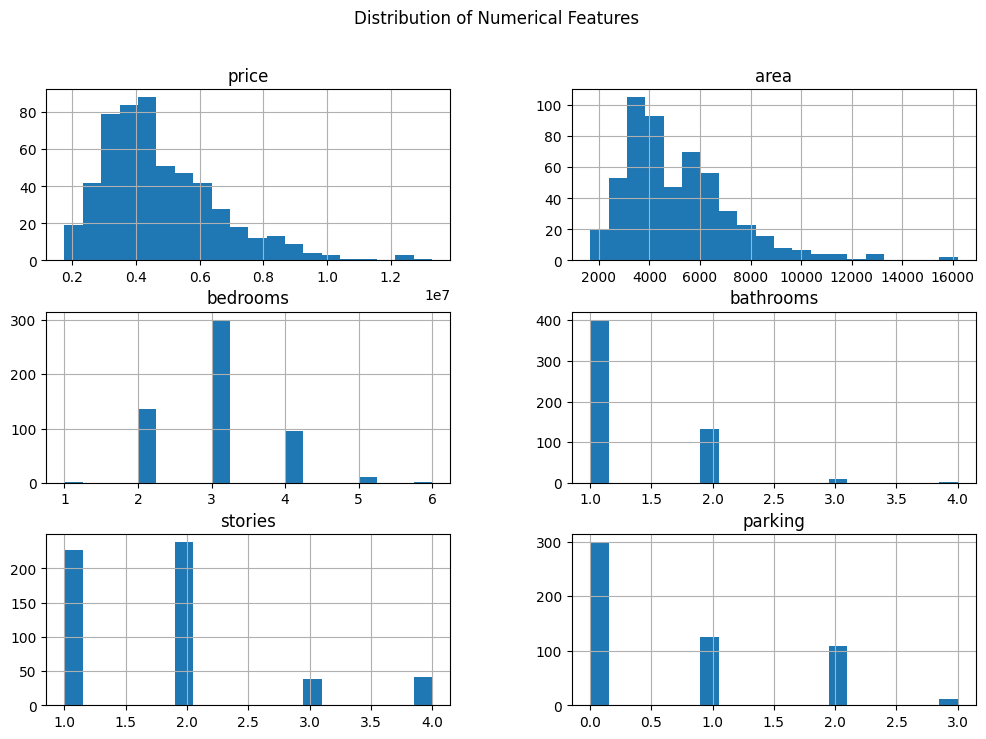

In [12]:
df.hist(
    figsize=(12,8),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features"
)

plt.show()

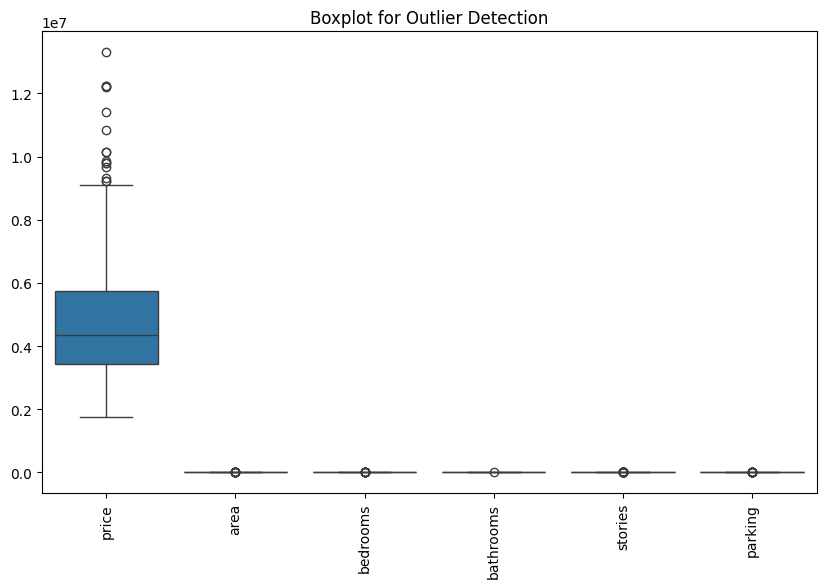

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title(
    "Boxplot for Outlier Detection"
)

plt.show()

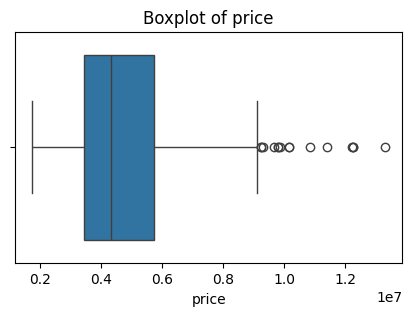

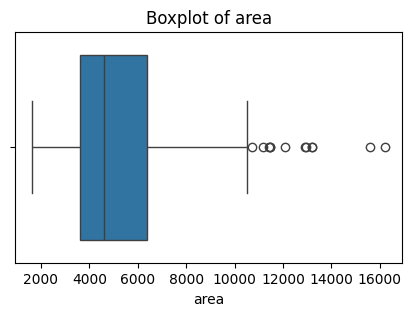

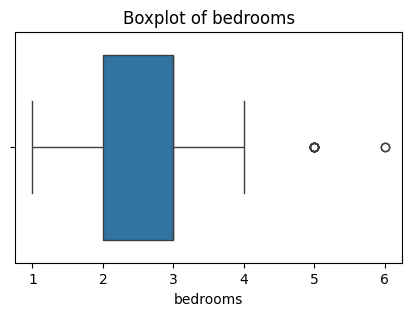

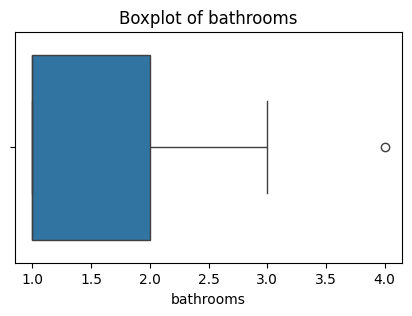

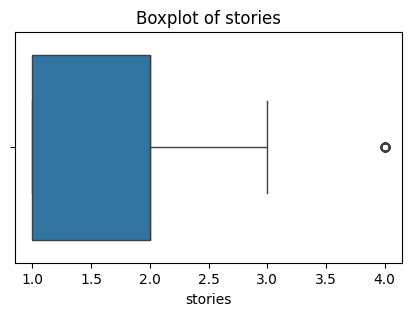

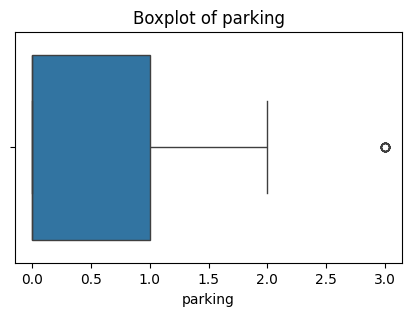

In [14]:
numerical_cols = [
    'price',
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

for col in numerical_cols:

    plt.figure(figsize=(5,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

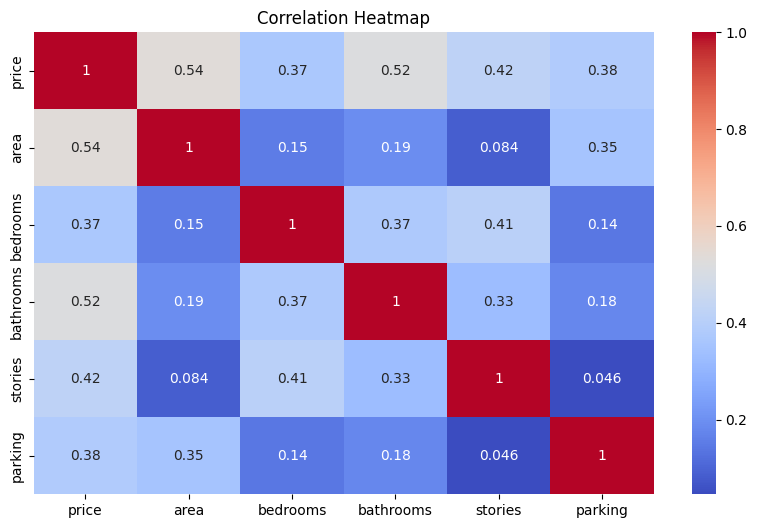

In [15]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

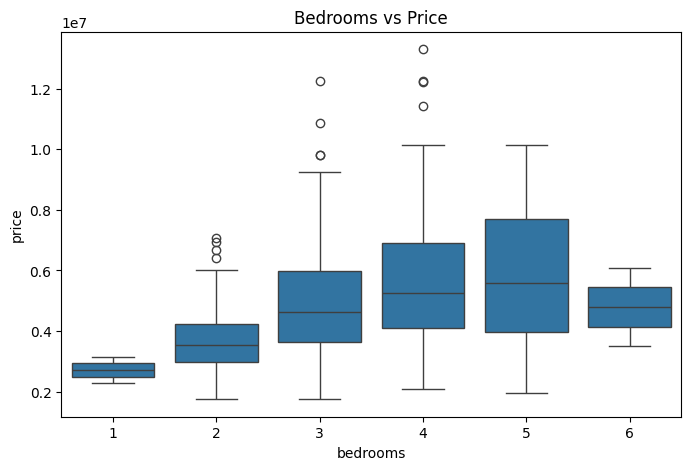

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='bedrooms',
    y='price'
)

plt.title("Bedrooms vs Price")

plt.show()

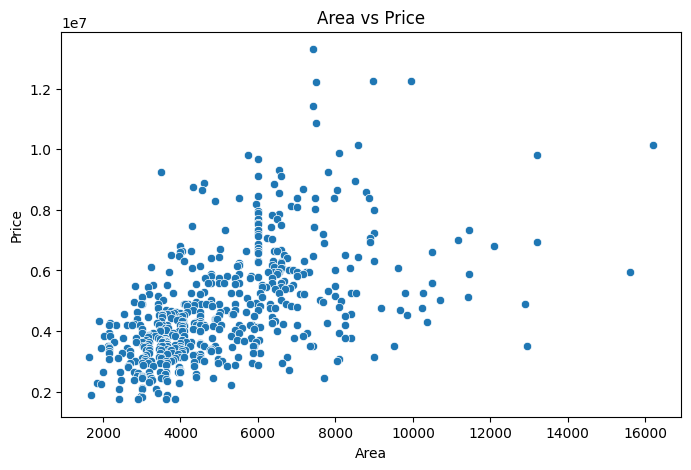

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='area',
    y='price'
)

plt.title("Area vs Price")

plt.xlabel("Area")

plt.ylabel("Price")

plt.show()

In [18]:
df = pd.read_csv("Housing.csv")

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB
None


In [19]:
#One-Hot Encoding
df = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

print(df.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2             1   
1  12250000  8960         4          4        4        3             1   
2  12250000  9960         3          2        2        2             1   
3  12215000  7500         4          2        2        3             1   
4  11410000  7420         4          1        2        2             1   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0              0             0                    0                    1   
1              0             0                    0                    1   
2              0             1                    0                    0   
3              0             1                    0                    1   
4              1             1                    0                    1   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0             1  

In [20]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='str')


In [21]:
''''''
X = df.drop('price', axis=1)

y = df['price']

print(X.shape)
print(y.shape)

(545, 13)
(545,)


In [22]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X Train:", X_train.shape)
print("X Test :", X_test.shape)
print("Y Train:", y_train.shape)
print("Y Test :", y_test.shape)

X Train: (436, 13)
X Test : (109, 13)
Y Train: (436,)
Y Test : (109,)


In [23]:
#Linear Regression Model Train
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [24]:
#Prediction
y_pred = model.predict(X_test)

print(y_pred[:5])

[5164653.90033967 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725955]


In [25]:
#Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 970043.4039201637
MSE : 1754318687330.6643
RMSE: 1324506.9600914388
R2 Score: 0.6529242642153184


In [26]:
#Coefficients
print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")

for feature, coef in zip(
    X.columns,
    model.coef_
):
    print(feature, ":", coef)

Intercept:
260032.35760741215

Coefficients:
area : 235.96880454139568
bedrooms : 76778.70163437817
bathrooms : 1094444.7861005974
stories : 407476.5949849111
parking : 224841.91327662626
mainroad_yes : 367919.94767957245
guestroom_yes : 231610.03717564975
basement_yes : 390251.1761810922
hotwaterheating_yes : 684649.8853387911
airconditioning_yes : 791426.7358431863
prefarea_yes : 629890.56531336
furnishingstatus_semi-furnished : -126881.81758510822
furnishingstatus_unfurnished : -413645.06222822214


In [27]:
import statsmodels

print(statsmodels.__version__)

0.14.6


In [28]:
#Check for Multi-Collinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(len(X.columns))
]

print(vif_data)

                            Feature        VIF
0                              area   8.276447
1                          bedrooms  16.652387
2                         bathrooms   9.417643
3                           stories   7.880730
4                           parking   1.986400
5                      mainroad_yes   6.884806
6                     guestroom_yes   1.473234
7                      basement_yes   2.019858
8               hotwaterheating_yes   1.091568
9               airconditioning_yes   1.767753
10                     prefarea_yes   1.494211
11  furnishingstatus_semi-furnished   2.386831
12     furnishingstatus_unfurnished   2.008632


In [29]:
#Ridge Regression
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train,
    y_train
)

ridge_pred = ridge_model.predict(X_test)

print("Ridge Model Trained Successfully")

Ridge Model Trained Successfully


In [30]:
#Evaluation
ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)

ridge_mse = mean_squared_error(
    y_test,
    ridge_pred
)

ridge_rmse = ridge_mse ** 0.5

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

print("Ridge MAE :", ridge_mae)
print("Ridge MSE :", ridge_mse)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R2 :", ridge_r2)

Ridge MAE : 970245.6821765776
Ridge MSE : 1756474279575.285
Ridge RMSE: 1325320.4441097574
Ridge R2 : 0.6524978002155009


In [31]:
#Comparison
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "R2 Score": [r2, ridge_r2]
})

print(comparison)

               Model  R2 Score
0  Linear Regression  0.652924
1   Ridge Regression  0.652498


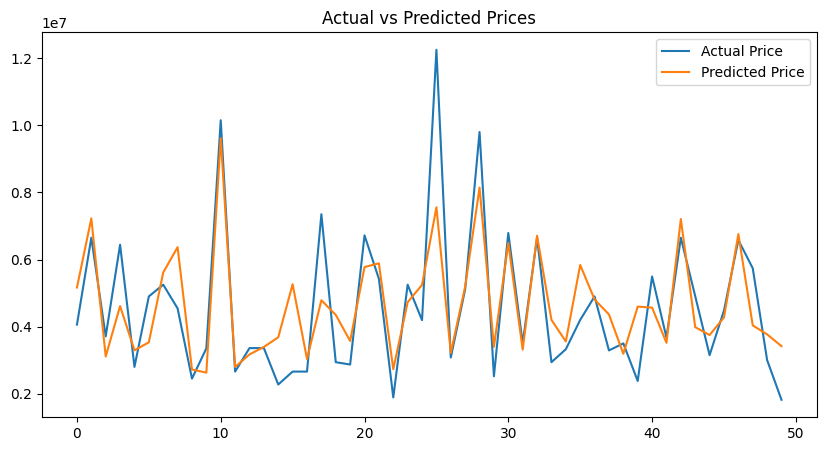

In [32]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:50],
    label='Actual Price'
)

plt.plot(
    y_pred[:50],
    label='Predicted Price'
)

plt.legend()

plt.title(
    'Actual vs Predicted Prices'
)

plt.show()

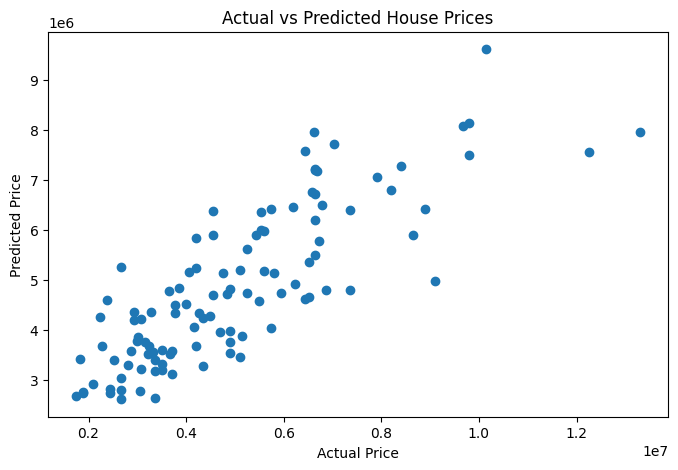

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [34]:
print("Best Model: Linear Regression")
print("R2 Score :", r2)

Best Model: Linear Regression
R2 Score : 0.6529242642153184


In [35]:
print("PROJECT SUMMARY")
print("Dataset : Housing.csv")
print("Algorithm : Linear Regression and Ridge Regression")
print("Encoding : One-Hot Encoding")
print("Evaluation Metrics : MAE, RMSE, R2 Score")
print("Best Model : Linear Regression")
print("Project Completed Successfully")

PROJECT SUMMARY
Dataset : Housing.csv
Algorithm : Linear Regression and Ridge Regression
Encoding : One-Hot Encoding
Evaluation Metrics : MAE, RMSE, R2 Score
Best Model : Linear Regression
Project Completed Successfully


# Conclusion

Linear Regression and Ridge Regression models were trained on the Housing Dataset.

Categorical variables were handled using One-Hot Encoding.

Multi-collinearity was checked using VIF.

Linear Regression achieved the best R² score of approximately 0.653.

The model can be used to estimate house prices based on housing features.